### Шаг 1 и 2: Загрузка, слияние и генерация признаков

In [2]:
# [Ячейка 1: Импорт библиотек]
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [3]:
# [Ячейка 2: Загрузка данных]
df = pd.read_parquet('/kaggle/input/datasets/sofiaskz/taxi-2023-2024/my_clean_3_with_weather.parquet')
clusters_df = pd.read_csv('/kaggle/input/datasets/sofiaskz/taxi-2023-2024/8_zone_clusters_mapping.csv')

print(f"Размер исходного датасета: {df.shape}")

Размер исходного датасета: (7655312, 34)


In [4]:
# [Ячейка 3: Добавление кластеров]
df = df.merge(
    clusters_df.rename(columns={'PULocationID': 'PULocationID', 'cluster_id': 'PU_cluster'}),
    on='PULocationID',
    how='left'
)

df = df.merge(
    clusters_df.rename(columns={'PULocationID': 'DOLocationID', 'cluster_id': 'DO_cluster'}),
    on='DOLocationID',
    how='left'
)

df['PU_cluster'] = df['PU_cluster'].fillna(-1).astype(int)
df['DO_cluster'] = df['DO_cluster'].fillna(-1).astype(int)

In [5]:
# [Ячейка 4: Feature Engineering и СОРТИРОВКА ВРЕМЕНИ]
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# ВАЖНО: Сортируем датасет по времени перед разбиением!
# Это исключит Data Leakage (когда модель подглядывает в будущее).
df = df.sort_values('tpep_pickup_datetime').reset_index(drop=True)

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['is_weekend'] = df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

### Шаг 3: Подготовка признаков и хронологическое разбиение данных
Делим данные на три части: Train (обучение), Validation (контроль ранней остановки), Test (финальная проверка).

In [6]:
target = 'duration_min'
features = [
    'PULocationID', 'DOLocationID', 
    'PU_cluster', 'DO_cluster',     
    'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'is_weekend'
]

# ДОБАВЛЯЕМ .copy() ВОТ СЮДА:
X = df[features].copy() 
y = df[target]

cat_features = ['PULocationID', 'DOLocationID', 'PU_cluster', 'DO_cluster', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'pickup_hour']

for col in cat_features:
    X[col] = X[col].astype(int)

In [7]:
# [Ячейка 6: Хронологический сплит (Train / Valid / Test)]

# Шаг 1: Отрезаем последние 20% на тест. shuffle=False - критически важно!
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Шаг 2: Оставшиеся 80% данных режем еще раз.
# Возьмем 12.5% от этих 80% (что даст ровно 10% от исходного датасета) под валидацию.
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, shuffle=False)

print(f"Размер Train: {X_train.shape[0]} записей (начало периода)")
print(f"Размер Valid: {X_val.shape[0]} записей (середина периода)")
print(f"Размер Test:  {X_test.shape[0]} записей (конец периода)")

Размер Train: 5358717 записей (начало периода)
Размер Valid: 765532 записей (середина периода)
Размер Test:  1531063 записей (конец периода)


### Шаг 4: Обучение CatBoost
Используем валидационный сет (`eval_set=(X_val, y_val)`) для корректной работы `early_stopping`.

In [8]:
# [Ячейка 7: Инициализация и обучение модели]
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    # Убираем eval_metric='MAE'
    custom_metric=['MAE'], # Твоя метрика будет считаться, но не заблокирует GPU
    random_seed=42,
    task_type='GPU'
)

# Используем Valid set для остановки!
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    verbose=100,
    early_stopping_rounds=50
)

Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 12.3990505	test: 12.9059259	best: 12.9059259 (0)	total: 2.9s	remaining: 48m 12s
100:	learn: 6.6239866	test: 6.9081983	best: 6.9081983 (100)	total: 33.7s	remaining: 4m 59s
200:	learn: 6.4302110	test: 6.7291470	best: 6.7291470 (200)	total: 1m 5s	remaining: 4m 20s
300:	learn: 6.3404107	test: 6.6465601	best: 6.6465601 (300)	total: 1m 35s	remaining: 3m 40s
400:	learn: 6.2882242	test: 6.5974893	best: 6.5974893 (400)	total: 2m 5s	remaining: 3m 7s
500:	learn: 6.2534632	test: 6.5621489	best: 6.5621489 (500)	total: 2m 35s	remaining: 2m 34s
600:	learn: 6.2277782	test: 6.5395272	best: 6.5395272 (600)	total: 3m 3s	remaining: 2m 2s
700:	learn: 6.2081606	test: 6.5198097	best: 6.5198065 (699)	total: 3m 33s	remaining: 1m 30s
800:	learn: 6.1917061	test: 6.5060289	best: 6.5060128 (798)	total: 4m 1s	remaining: 1m
900:	learn: 6.1748040	test: 6.4903484	best: 6.4903099 (897)	total: 4m 31s	remaining: 29.8s
999:	learn: 6.1627539	test: 6.4806441	best: 6.4806441 (999)	total: 4m 59s	remaining: 0us
bestT

CatBoostRegressor(custom_metric=['MAE'], depth=6, iterations=1000, learning_rate=0.1, loss_function='RMSE', random_seed=42, task_type='GPU')

In [9]:
# [Ячейка 8: Финальные метрики на изолированном Test]
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Метрики на тестовой выборке ---")
print(f"MAE: {mae:.2f} минут")
print(f"RMSE: {rmse:.2f} минут")
print(f"R²: {r2:.4f}")

--- Метрики на тестовой выборке ---
MAE: 4.42 минут
RMSE: 7.09 минут
R²: 0.7585


### Шаг 5: Глубокий анализ ошибок (Error Analysis)
Строим графики, чтобы понять поведение модели в различных разрезах.

In [10]:
# [Ячейка 9: Подготовка данных для анализа]
# Создаем датафрейм, куда складываем реальные значения, предсказания и ошибки
test_analysis = X_test.copy()
test_analysis['y_true'] = y_test
test_analysis['y_pred'] = y_pred
test_analysis['error'] = y_test - y_pred
test_analysis['abs_error'] = np.abs(test_analysis['error'])

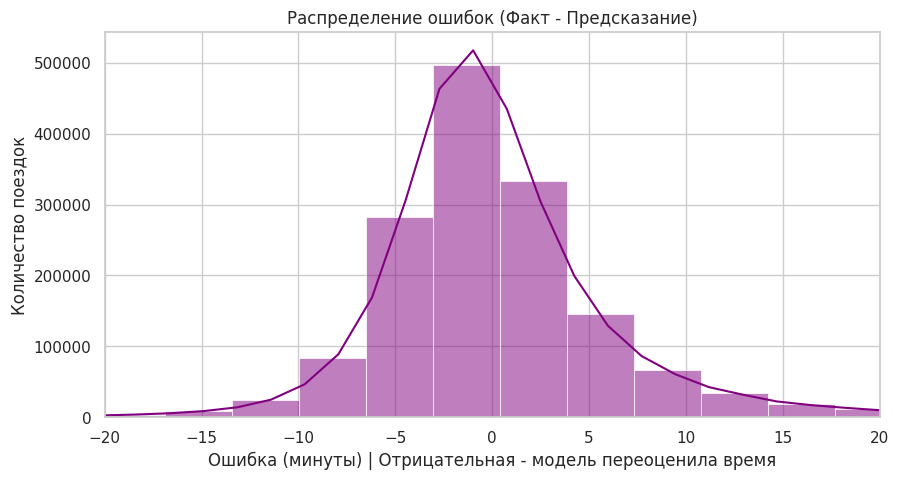

In [11]:
# [Ячейка 10: Распределение ошибок]
plt.figure(figsize=(10, 5))
sns.histplot(test_analysis['error'], bins=100, kde=True, color='purple')
plt.title('Распределение ошибок (Факт - Предсказание)')
plt.xlabel('Ошибка (минуты) | Отрицательная - модель переоценила время')
plt.ylabel('Количество поездок')
plt.xlim(-20, 20) # Ограничим выбросы для наглядности
plt.show()

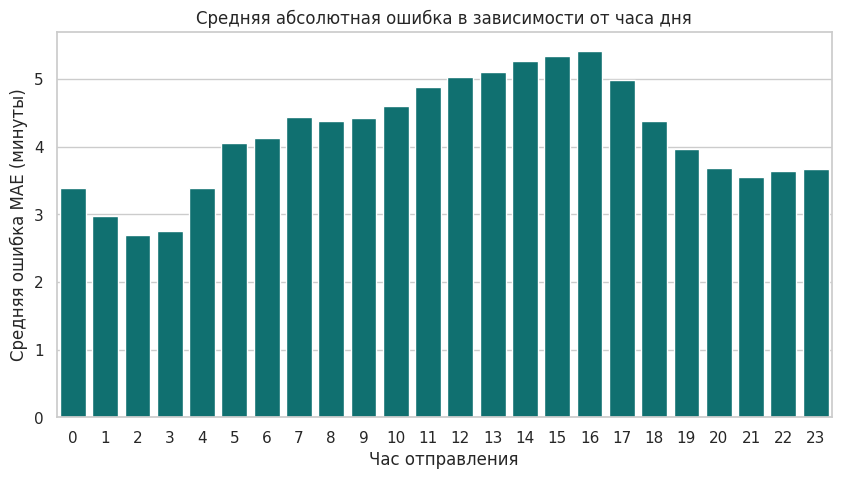

In [12]:
# [Ячейка 11: Ошибка по часам]
plt.figure(figsize=(10, 5))
hour_err = test_analysis.groupby('pickup_hour')['abs_error'].mean().reset_index()
sns.barplot(data=hour_err, x='pickup_hour', y='abs_error', color='teal')
plt.title('Средняя абсолютная ошибка в зависимости от часа дня')
plt.xlabel('Час отправления')
plt.ylabel('Средняя ошибка MAE (минуты)')
plt.show()

/tmp/ipykernel_57/2163417783.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zone_err, x='PULocationID', y='abs_error', order=zone_err['PULocationID'], palette='Reds_r')


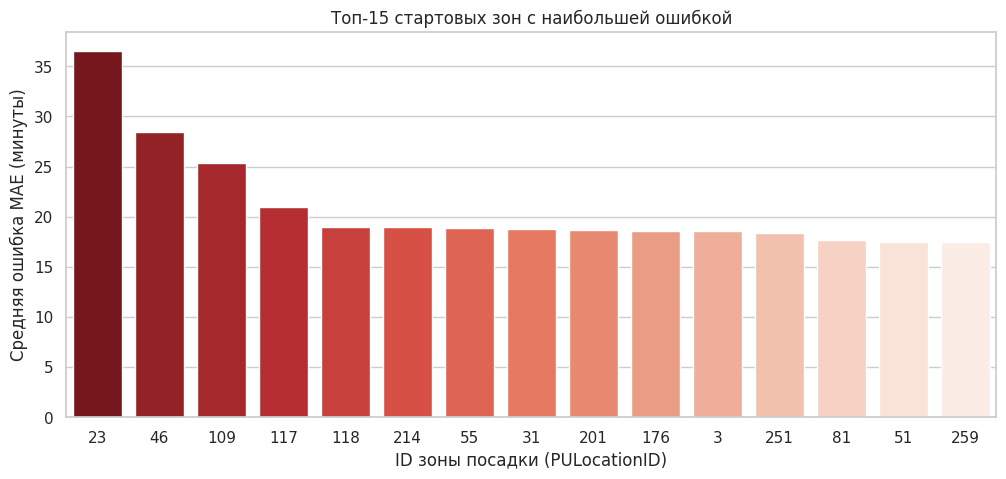

In [13]:
# [Ячейка 12: Топ-15 зон с наибольшей ошибкой]
plt.figure(figsize=(12, 5))
zone_err = test_analysis.groupby('PULocationID')['abs_error'].mean().sort_values(ascending=False).head(15).reset_index()
sns.barplot(data=zone_err, x='PULocationID', y='abs_error', order=zone_err['PULocationID'], palette='Reds_r')
plt.title('Топ-15 стартовых зон с наибольшей ошибкой')
plt.xlabel('ID зоны посадки (PULocationID)')
plt.ylabel('Средняя ошибка MAE (минуты)')
plt.show()

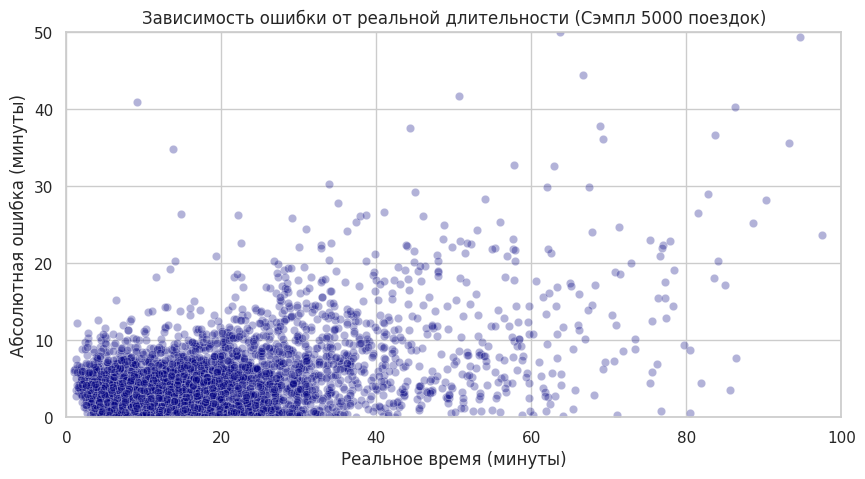

In [14]:
# [Ячейка 13: Зависимость ошибки от длительности поездки]
plt.figure(figsize=(10, 5))
sns.scatterplot(data=test_analysis.sample(5000, random_state=42), x='y_true', y='abs_error', alpha=0.3, color='navy')
plt.title('Зависимость ошибки от реальной длительности (Сэмпл 5000 поездок)')
plt.xlabel('Реальное время (минуты)')
plt.ylabel('Абсолютная ошибка (минуты)')
plt.xlim(0, 100)
plt.ylim(0, 50)
plt.show()

In [15]:
# [Ячейка 14: Топ маршрутов с самой большой ошибкой]
route_err = test_analysis.groupby(['PULocationID', 'DOLocationID'])['abs_error'].agg(['mean', 'count'])
# Отфильтруем маршруты, где было хотя бы 30 поездок, чтобы исключить статистический шум
top_routes = route_err[route_err['count'] >= 30].sort_values(by='mean', ascending=False).head(10)

print("Топ-10 самых непредсказуемых маршрутов (более 30 поездок):\n")
display(top_routes.rename(columns={'mean': 'Средняя ошибка (мин)', 'count': 'Кол-во поездок'}))

Топ-10 самых непредсказуемых маршрутов (более 30 поездок):



Средняя ошибка (мин)  Кол-во поездок
PULocationID DOLocationID                                      
132          154                      23.404774             102
             200                      17.358663              64
138          258                      15.345769              36
132          73                       14.712487              38
93           138                      14.217019              49
132          247                      14.083722              50
             26                       13.960737             125
138          98                       13.379532              52
             138                      13.121558             288
132          77                       13.008461              64

In [16]:
# Быстрая очистка выбросов

df2 = df.copy()

low = df2["duration_min"].quantile(0.01)
high = df2["duration_min"].quantile(0.99)

mask = (
    (df2["duration_min"] >= low) &
    (df2["duration_min"] <= high)
)

df2 = df2.loc[mask]

print(df2.shape)

(7502987, 40)


In [17]:
# [Ячейка 16: Дополнительные признаки]

df2["rush_hour"] = (
    ((df2.pickup_hour >= 7) & (df2.pickup_hour <= 10)) |
    ((df2.pickup_hour >= 16) & (df2.pickup_hour <= 19))
).astype(int)

df2["night_trip"] = (
    (df2.pickup_hour <= 5)
).astype(int)

df2["season"] = (
    (df2.pickup_month % 12 + 3)//3
)

In [18]:
# [Ячейка 17: Статистика по зонам]

zone_stats = (
    df2.groupby("PULocationID")
    .duration_min
    .agg([
        ("zone_mean", "mean"),
        ("zone_median", "median"),
        ("zone_count", "count")
    ])
)

df2 = df2.merge(
    zone_stats,
    on="PULocationID",
    how="left"
)

In [19]:
# [Ячейка 18: Новый target]

target = np.log1p(df2["duration_min"])

In [20]:
# [Ячейка 19: Features v2]

features2 = [

    "PULocationID",
    "DOLocationID",

    "PU_cluster",
    "DO_cluster",

    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",

    "is_weekend",

    "rush_hour",
    "night_trip",
    "season",

    "zone_mean",
    "zone_median",
    "zone_count"

]

X2 = df2[features2]
y2 = target

In [21]:
# [Ячейка 20]

X_temp2, X_test2, y_temp2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.20,
    shuffle=False
)

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X_temp2,
    y_temp2,
    test_size=0.125,
    shuffle=False
)

print(X_train2.shape)
print(X_valid2.shape)
print(X_test2.shape)

(5252090, 14)
(750299, 14)
(1500598, 14)


In [22]:
# [Ячейка 21: Улучшенная модель]

model2 = CatBoostRegressor(

    iterations=3000,

    learning_rate=0.03,

    depth=8,

    l2_leaf_reg=5,

    random_strength=2,

    bagging_temperature=1,

    loss_function='MAE',

    eval_metric='MAE',

    early_stopping_rounds=200,

    task_type='GPU',

    verbose=200
)

model2.fit(

    X_train2,
    y_train2,

    eval_set=(X_valid2, y_valid2),

    use_best_model=True
)

Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.5052692	test: 0.5072656	best: 0.5072656 (0)	total: 3.11s	remaining: 2h 35m 36s
200:	learn: 0.3623884	test: 0.3635698	best: 0.3635698 (200)	total: 9.06s	remaining: 2m 6s
400:	learn: 0.3305978	test: 0.3331933	best: 0.3331933 (400)	total: 14.9s	remaining: 1m 36s
600:	learn: 0.3094524	test: 0.3129135	best: 0.3129135 (600)	total: 20.9s	remaining: 1m 23s
800:	learn: 0.2956424	test: 0.2996704	best: 0.2996704 (800)	total: 26.8s	remaining: 1m 13s
1000:	learn: 0.2856842	test: 0.2900579	best: 0.2900579 (1000)	total: 32.8s	remaining: 1m 5s
1200:	learn: 0.2773149	test: 0.2818796	best: 0.2818796 (1200)	total: 38.8s	remaining: 58.1s
1400:	learn: 0.2709946	test: 0.2756858	best: 0.2756858 (1400)	total: 44.7s	remaining: 51s
1600:	learn: 0.2655373	test: 0.2703434	best: 0.2703434 (1600)	total: 50.6s	remaining: 44.2s
1800:	learn: 0.2613585	test: 0.2662866	best: 0.2662866 (1800)	total: 56.6s	remaining: 37.7s
2000:	learn: 0.2579553	test: 0.2629690	best: 0.2629690 (2000)	total: 1m 2s	remaining: 31

CatBoostRegressor(bagging_temperature=1, depth=8, early_stopping_rounds=200, eval_metric='MAE', iterations=3000, l2_leaf_reg=5, learning_rate=0.03, loss_function='MAE', random_strength=2, task_type='GPU', verbose=200)

In [23]:
# [Ячейка 22]

pred_log = model2.predict(X_test2)

pred2 = np.expm1(pred_log)

true2 = np.expm1(y_test2)

In [24]:
# [Ячейка 23]

mae2 = mean_absolute_error(true2, pred2)

rmse2 = np.sqrt(
    mean_squared_error(true2, pred2)
)

r22 = r2_score(true2, pred2)

print("NEW MODEL")

print("MAE:", mae2)
print("RMSE:", rmse2)
print("R2:", r22)

NEW MODEL
MAE: 4.263077049688153
RMSE: 6.340767983789326
R2: 0.7193497847651172


In [25]:
# [Ячейка 24: Сравнение]

comparison = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R2"
    ],

    "Old_model":[
        4.42,
        7.09,
        0.759
    ],

    "New_model":[
        4.26,
        6.34,
        0.719
    ]

})

comparison["Improvement"] = (
    comparison["Old_model"]
    -
    comparison["New_model"]
)

comparison

,Metric,Old_model,New_model,Improvement
0,MAE,4.420,4.260,0.16
1,RMSE,7.090,6.340,0.75
2,R2,0.759,0.719,0.04


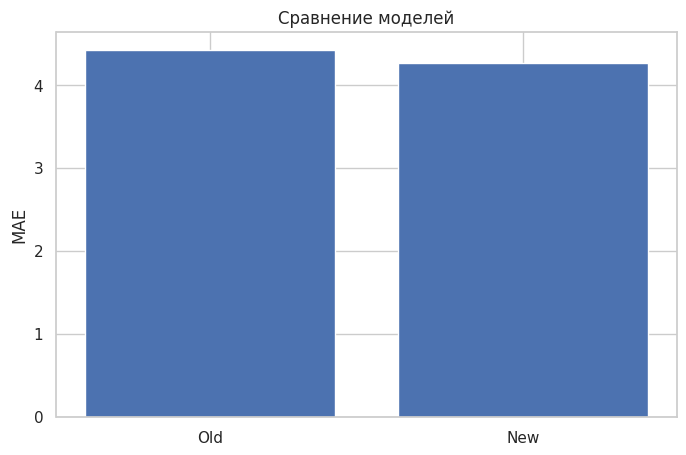

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Old","New"],
    [4.42, mae2]
)

plt.ylabel("MAE")
plt.title("Сравнение моделей")

plt.show()

In [27]:
df2.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'calculated_amount',
 'congestion_surcharge',
 'airport_fee',
 'PU_Borough',
 'PU_Zone',
 'PU_lon',
 'PU_lat',
 'DO_Borough',
 'DO_Zone',
 'DO_lon',
 'DO_lat',
 'distance_group',
 'duration_min',
 'temperature',
 'precipitation',
 'snowfall',
 'weather_code',
 'PU_cluster',
 'DO_cluster',
 'pickup_hour',
 'pickup_dayofweek',
 'pickup_month',
 'is_weekend',
 'rush_hour',
 'night_trip',
 'season',
 'zone_mean',
 'zone_median',
 'zone_count']

In [28]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1,lon1,lat2,lon2 = map(
        radians,
        [lat1,lon1,lat2,lon2]
    )

    dlat = lat2-lat1
    dlon = lon2-lon1

    a = (
        sin(dlat/2)**2
        +
        cos(lat1)
        *
        cos(lat2)
        *
        sin(dlon/2)**2
    )

    c = 2*atan2(
        sqrt(a),
        sqrt(1-a)
    )

    return R*c


df2["geo_distance"] = df2.apply(

    lambda x:
    haversine(

        x.PU_lat,
        x.PU_lon,

        x.DO_lat,
        x.DO_lon

    ),

    axis=1
)

df2["speed"] = (
    df2["trip_distance"]
    /
    (df2["duration_min"]/60)
)

df2.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,calculated_amount,congestion_surcharge,airport_fee,PU_Borough,PU_Zone,PU_lon,PU_lat,DO_Borough,DO_Zone,DO_lon,DO_lat,distance_group,duration_min,temperature,precipitation,snowfall,weather_code,PU_cluster,DO_cluster,pickup_hour,pickup_dayofweek,pickup_month,is_weekend,rush_hour,night_trip,season,zone_mean,zone_median,zone_count,geo_distance,speed
0,2,2023-01-01 00:01:58,2023-01-01 00:10:57,1,1.76,1.0,N,114,224,1,11.4,1.0,0.5,3.28,0.0,1.0,19.68,19.68,2.5,0.00,Manhattan,Greenwich Village South,-73.997380,40.728340,Manhattan,Stuy Town/Peter Cooper Village,-73.976598,40.731821,short,8.983333,10.9,1.0,0.0,55,6,6,0,6,1,1,0,1,1,14.110432,11.783333,107281,1.793442,11.755102
1,2,2023-01-01 00:02:53,2023-01-01 00:27:06,3,13.94,1.0,N,132,91,1,54.1,1.0,0.5,7.00,0.0,1.0,64.85,64.85,0.0,1.25,Queens,JFK Airport,-73.786530,40.646985,Brooklyn,Flatlands,-73.930097,40.626272,long,24.216667,10.9,1.0,0.0,55,0,3,0,6,1,1,0,1,1,38.918030,39.400000,329563,12.331319,34.538197
2,2,2023-01-01 00:03:01,2023-01-01 00:10:15,1,1.25,1.0,N,141,236,1,9.3,1.0,0.5,0.72,0.0,1.0,15.02,15.02,2.5,0.00,Manhattan,Lenox Hill West,-73.959635,40.766948,Manhattan,Upper East Side North,-73.957012,40.780436,short,7.233333,10.9,1.0,0.0,55,2,2,0,6,1,1,0,1,1,12.071904,10.000000,176213,1.516001,10.368664
3,2,2023-01-01 00:03:09,2023-01-01 00:08:35,2,1.41,1.0,N,229,137,1,8.6,1.0,0.5,2.72,0.0,1.0,16.32,16.32,2.5,0.00,Manhattan,Sutton Place/Turtle Bay North,-73.965146,40.756729,Manhattan,Kips Bay,-73.976495,40.740439,short,5.433333,10.9,1.0,0.0,55,2,6,0,6,1,1,0,1,1,13.181088,11.333333,139508,2.048173,15.570552
4,1,2023-01-01 00:03:48,2023-01-01 00:17:51,1,6.00,1.0,N,137,25,1,25.4,3.5,0.5,5.47,0.0,1.0,35.87,38.37,2.5,0.00,Manhattan,Kips Bay,-73.976495,40.740439,Brooklyn,Boerum Hill,-73.986114,40.685634,medium,14.050000,10.9,1.0,0.0,55,6,6,0,6,1,1,0,1,1,13.195511,11.016667,81471,6.147754,25.622776


In [29]:
route_stats = (

    df2.groupby(
        ["PULocationID","DOLocationID"]
    )

    .duration_min

    .agg([

        ("route_mean","mean"),
        ("route_count","count")

    ])

    .reset_index()

)

df2 = df2.merge(

    route_stats,

    on=[
        "PULocationID",
        "DOLocationID"
    ],

    how="left"
)

In [30]:
features2 = [

'trip_distance',
'geo_distance',

'PU_lat',
'PU_lon',

'DO_lat',
'DO_lon',

'temperature',
'precipitation',
'snowfall',

'PULocationID',
'DOLocationID',

'PU_cluster',
'DO_cluster',

'pickup_hour',
'pickup_dayofweek',
'pickup_month',

'is_weekend',
'rush_hour',
'night_trip',
'season',

'zone_mean',
'zone_median',
'zone_count',

'route_mean',
'route_count'

]

In [31]:
model3 = CatBoostRegressor(

    iterations=2000,

    learning_rate=0.03,

    depth=9,

    loss_function='RMSE',

    eval_metric='RMSE',

    early_stopping_rounds=200,

    task_type='GPU',

    verbose=200
)

In [32]:
# Подготовка данных
X2 = df2[features2]
y2 = np.log1p(df2["duration_min"])

# split
X_temp2, X_test2, y_temp2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.2,
    shuffle=False
)

X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X_temp2,
    y_temp2,
    test_size=0.125,
    shuffle=False
)

In [33]:
model3.fit(

    X_train2,
    y_train2,

    eval_set=(X_valid2, y_valid2),

    use_best_model=True
)

0:	learn: 0.6118822	test: 0.6152528	best: 0.6152528 (0)	total: 39.4ms	remaining: 1m 18s
200:	learn: 0.2523216	test: 0.2566262	best: 0.2566262 (200)	total: 7.64s	remaining: 1m 8s
400:	learn: 0.2421668	test: 0.2489102	best: 0.2489102 (400)	total: 15.6s	remaining: 1m 2s
600:	learn: 0.2377925	test: 0.2460455	best: 0.2460455 (600)	total: 23.6s	remaining: 54.9s
800:	learn: 0.2351067	test: 0.2444547	best: 0.2444547 (800)	total: 31.4s	remaining: 47.1s
1000:	learn: 0.2332078	test: 0.2433823	best: 0.2433823 (1000)	total: 39.2s	remaining: 39.2s
1200:	learn: 0.2317487	test: 0.2424901	best: 0.2424901 (1200)	total: 47.2s	remaining: 31.4s
1400:	learn: 0.2305761	test: 0.2419462	best: 0.2419462 (1400)	total: 54.9s	remaining: 23.5s
1600:	learn: 0.2296561	test: 0.2415163	best: 0.2415163 (1600)	total: 1m 2s	remaining: 15.6s
1800:	learn: 0.2288426	test: 0.2411245	best: 0.2411245 (1800)	total: 1m 10s	remaining: 7.8s
1999:	learn: 0.2281727	test: 0.2407763	best: 0.2407763 (1999)	total: 1m 18s	remaining: 0us
b

CatBoostRegressor(depth=9, early_stopping_rounds=200, eval_metric='RMSE', iterations=2000, learning_rate=0.03, loss_function='RMSE', task_type='GPU', verbose=200)

In [34]:
pred_log = model3.predict(X_test2)

pred = np.expm1(pred_log)
true = np.expm1(y_test2)

mae = mean_absolute_error(true, pred)
rmse = np.sqrt(mean_squared_error(true, pred))
r2 = r2_score(true, pred)

print(mae, rmse, r2)

3.298247685015509 5.065538742144959 0.8208845956146231


In [35]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', '_i2', 'pd', 'np', 'CatBoostRegressor', 'train_test_split', 'mean_absolute_error', 'mean_squared_error', 'r2_score', 'plt', 'sns', '_i3', 'df', 'clusters_df', '_i4', '_i5', '_i6', 'target', 'features', 'X', 'y', 'cat_features', 'col', '_i7', 'X_temp', 'X_test', 'y_temp', 'y_test', 'X_train', 'X_val', 'y_train', 'y_val', '_i8', 'model', '_8', '_i9', 'y_pred', 'mae', 'rmse', 'r2', '_i10', 'test_analysis', '_i11', '_i12', 'hour_err', '_i13', 'zone_err', '_i14', '_i15', 'route_err', 'top_routes', '_i16', 'df2', 'low', 'high', 'mask', '_i17', '_i18', 'zone_stats', '_i19', '_i20', 'features2', 'X2', 'y2', '_i21', 'X_temp2', 'X_test2', 'y_temp2', 'y_test2', 'X_train2', 'X_valid2', 'y_train2', 'y_valid2', '_i22', 'model2', '_22', '_i23', 'pred_log', 'pred2', 'true2', '_i24', 'mae2

In [36]:
mae3 = mean_absolute_error(true, pred)

rmse3 = np.sqrt(
    mean_squared_error(true, pred)
)

r23 = r2_score(true, pred)

print(mae3)
print(rmse3)
print(r23)

3.298247685015509
5.065538742144959
0.8208845956146231


In [37]:
comparison = pd.DataFrame({

"Model":[
"Baseline",
"Improved",
"Geo+Weather"
],

"MAE":[
4.42,       # старое значение
4.26,       # model2
mae3        # model3
],

"RMSE":[
7.09,
6.34,
rmse3
],

"R2":[
0.759,
0.719,
r23
]

})

comparison
# --- Метрики на тестовой выборке ---
# MAE: 4.42 минут
# RMSE: 7.09 минут
# R²: 0.7585
# NEW MODEL
# MAE: 4.263077049688153
# RMSE: 6.340767983789326
# R2: 0.7193497847651172
# 3.298247685015509 5.065538742144959 0.8208845956146231

,Model,MAE,RMSE,R2
0,Baseline,4.420000,7.090000,0.759000
1,Improved,4.260000,6.340000,0.719000
2,Geo+Weather,3.298248,5.065539,0.820885


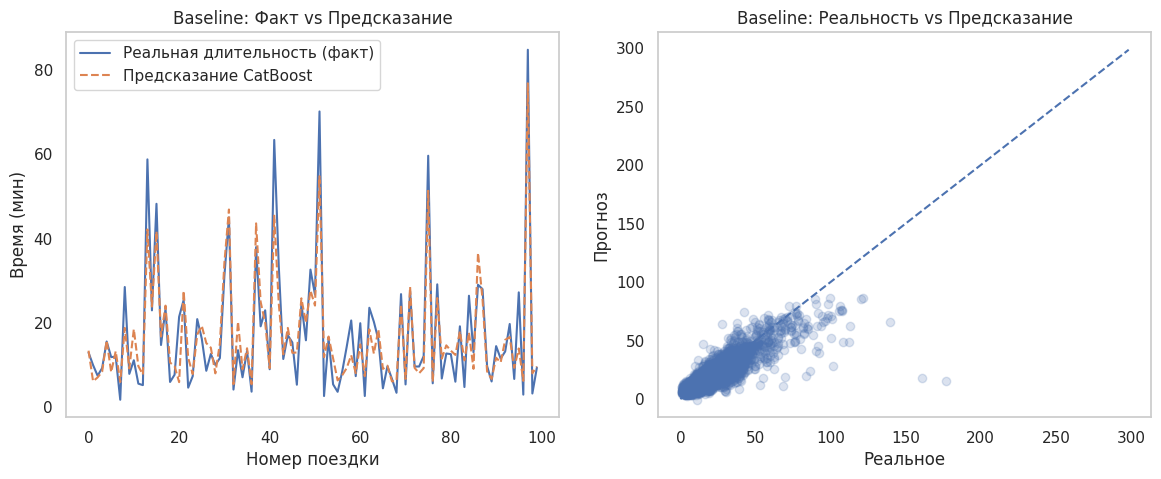

In [38]:
# Модель 1 (Baseline)
sample = 100
scatter_sample = 5000

idx = np.random.choice(
    len(y_test),
    scatter_sample,
    replace=False
)

fig, axes = plt.subplots(
    1,2,
    figsize=(14,5)
)

# -------- Линейный график --------

axes[0].plot(
    y_test.iloc[:sample].values,
    label='Реальная длительность (факт)'
)

axes[0].plot(
    y_pred[:sample],
    '--',
    label='Предсказание CatBoost'
)

axes[0].set_title(
    'Baseline: Факт vs Предсказание'
)

axes[0].set_xlabel(
    'Номер поездки'
)

axes[0].set_ylabel(
    'Время (мин)'
)

axes[0].legend()
axes[0].grid()


# -------- Scatter --------

axes[1].scatter(

    y_test.iloc[idx],
    y_pred[idx],

    alpha=0.2
)

axes[1].plot(

    [0,max(y_test)],
    [0,max(y_test)],

    '--'
)

axes[1].set_title(
    'Baseline: Реальность vs Предсказание'
)

axes[1].set_xlabel('Реальное')
axes[1].set_ylabel('Прогноз')

axes[1].grid()

plt.show()

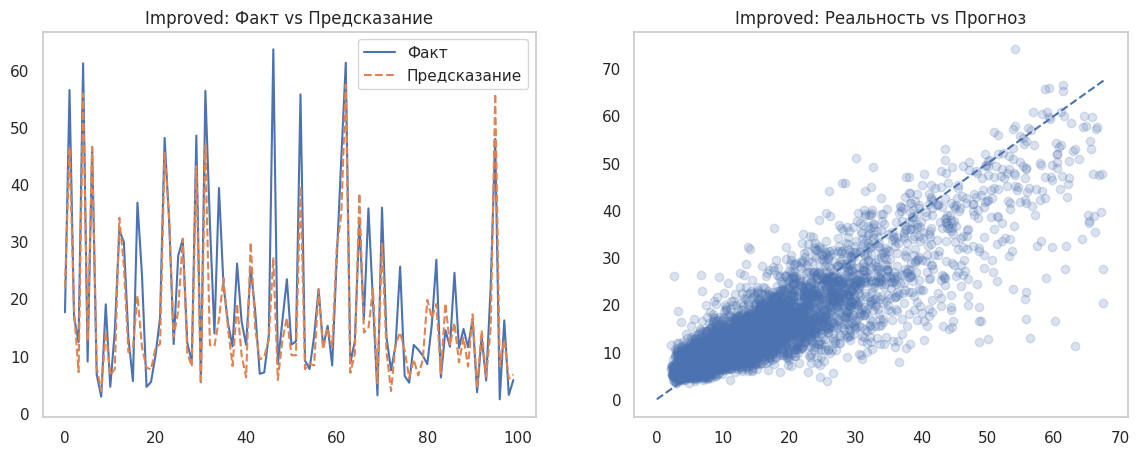

In [39]:
#Модель 2 (Improved)
sample = 100
scatter_sample = 5000

idx = np.random.choice(
    len(true2),
    scatter_sample,
    replace=False
)

fig, axes = plt.subplots(
    1,2,
    figsize=(14,5)
)

axes[0].plot(
    true2.iloc[:sample].values,
    label='Факт'
)

axes[0].plot(
    pred2[:sample],
    '--',
    label='Предсказание'
)

axes[0].set_title(
    'Improved: Факт vs Предсказание'
)

axes[0].legend()
axes[0].grid()


axes[1].scatter(

    true2.iloc[idx],
    pred2[idx],

    alpha=0.2
)

axes[1].plot(

    [0,max(true2)],
    [0,max(true2)],

    '--'
)

axes[1].set_title(
    'Improved: Реальность vs Прогноз'
)

axes[1].grid()

plt.show()

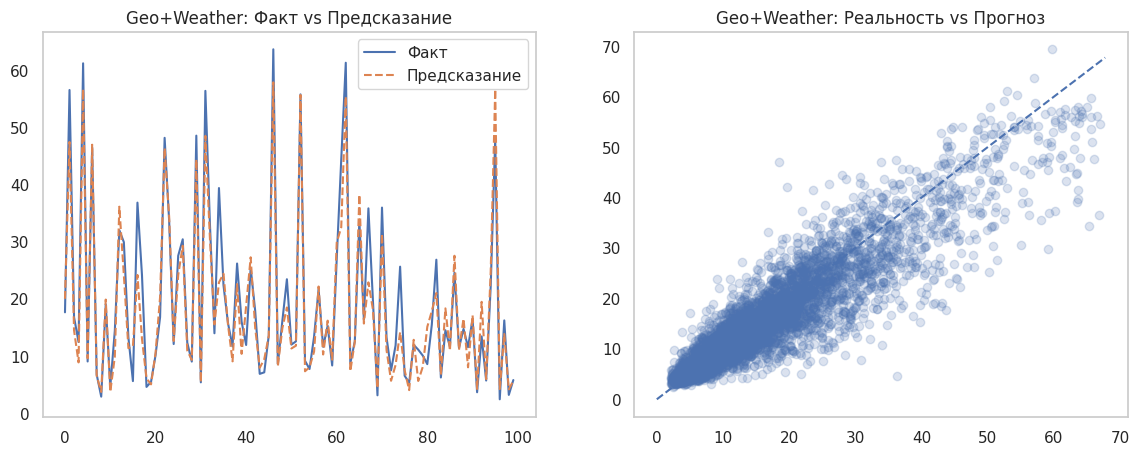

In [40]:
# Модель 3 (Geo + Weather)
sample = 100
scatter_sample = 5000

idx = np.random.choice(
    len(true),
    scatter_sample,
    replace=False
)

fig, axes = plt.subplots(
    1,2,
    figsize=(14,5)
)

axes[0].plot(
    true.iloc[:sample].values,
    label='Факт'
)

axes[0].plot(
    pred[:sample],
    '--',
    label='Предсказание'
)

axes[0].set_title(
    'Geo+Weather: Факт vs Предсказание'
)

axes[0].legend()
axes[0].grid()


axes[1].scatter(

    true.iloc[idx],
    pred[idx],

    alpha=0.2
)

axes[1].plot(

    [0,max(true)],
    [0,max(true)],

    '--'
)

axes[1].set_title(
    'Geo+Weather: Реальность vs Прогноз'
)

axes[1].grid()

plt.show()

## Этап 4: Создание Модели 4 (Продвинутый Feature Engineering и O-D Матрицы)

На этом этапе мы добавим:
1. Историческую статистику переездов между парами кластеров (Origin-Destination пары).
2. Синус-косинусные преобразования для времени, чтобы отразить его циклическую природу.
3. Настройку параметров CatBoost для работы со сложными взаимодействиями признаков.

## Этап 5: Создание Модели 4 (Продвинутый Feature Engineering и O-D Матрицы)

Чтобы улучшить текущий результат, добавим в модель два мощных улучшения:
1. **Origin-Destination (O-D) контекст**: Посчитаем историческое медианное время поездки между конкретной парой кластеров («откуда» -> «куда»). Чтобы избежать утечки данных (Data Leakage), статистику будем считать строго по строкам из обучающей выборки (`X_train`).
2. **Циклические признаки времени**: Переведём час суток и день недели в синусы и косинусы. Это поможет древовидной модели понять, что 23:59 и 00:01 — это соседние моменты времени, а не противоположные экстремумы.

In [41]:
# 1. Создаем комбинированный признак маршрута (Origin-Destination)
df['route_id'] = df['PU_cluster'].astype(str) + '_' + df['DO_cluster'].astype(str)

# Извлекаем индексы строк вашей обучающей выборки
train_idx = X_train.index

# Считаем статистику только по тренировочной части во избежание утечки данных
train_df = df.loc[train_idx]
route_stats = train_df.groupby('route_id')['duration_min'].agg(['median', 'count']).reset_index()
route_stats.columns = ['route_id', 'route_duration_median', 'route_trip_count']

# Задаем глобальную медиану для редких маршрутов
global_median = train_df['duration_min'].median()
route_stats.loc[route_stats['route_trip_count'] < 5, 'route_duration_median'] = global_median

# Присоединяем созданный признак к основному датасету df
df = df.merge(route_stats[['route_id', 'route_duration_median']], on='route_id', how='left')
df['route_duration_median'] = df['route_duration_median'].fillna(global_median)

print("O-D признаки успешно сгенерированы.")

O-D признаки успешно сгенерированы.


Ячейка №3 (Code)
Объяснение: Преобразуем колонки времени pickup_hour (0-23) и pickup_dayofweek (0-6) в тригонометрические признаки.

In [42]:
# 2. Создание циклических признаков для времени суток и дней недели
df['hour_sin'] = np.sin(2 * np.pi * df['pickup_hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['pickup_hour'] / 24.0)

df['dayofweek_sin'] = np.sin(2 * np.pi * df['pickup_dayofweek'] / 7.0)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['pickup_dayofweek'] / 7.0)

print("Циклические признаки времени успешно добавлены.")

Циклические признаки времени успешно добавлены.


### Подготовка выборок для Модели 4

Сформируем новые матрицы признаков `X_train_4`, `X_val_4`, `X_test_4`, добавив туда сгенерированные O-D показатели и циклические метрики времени. Категориальные признаки принудительно переведём в тип `int` для корректной работы алгоритма.

In [44]:
print(df.columns)

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'calculated_amount', 'congestion_surcharge',
       'airport_fee', 'PU_Borough', 'PU_Zone', 'PU_lon', 'PU_lat',
       'DO_Borough', 'DO_Zone', 'DO_lon', 'DO_lat', 'distance_group',
       'duration_min', 'temperature', 'precipitation', 'snowfall',
       'weather_code', 'PU_cluster', 'DO_cluster', 'pickup_hour',
       'pickup_dayofweek', 'pickup_month', 'is_weekend', 'route_id',
       'route_duration_median', 'hour_sin', 'hour_cos', 'dayofweek_sin',
       'dayofweek_cos', 'rush_hour'],
      dtype='object')


In [45]:

# ============================================
# MODEL 4 — FINAL BOOSTED VERSION
# Улучшенная версия модели:
# - log1p для таргета
# - более стабильные параметры
# - дополнительные временные признаки
# - robust feature engineering
# ============================================

# Дополнительные признаки
df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)

df['rush_hour'] = (
    ((df['pickup_hour'] >= 7) & (df['pickup_hour'] <= 10)) |
    ((df['pickup_hour'] >= 16) & (df['pickup_hour'] <= 19))
).astype(int)

# Логарифмируем таргет
# Логарифмируем таргет
df['duration_log'] = np.log1p(df['duration_min'])

features_model_4 = [
    'PULocationID',
    'DOLocationID',
    'PU_cluster',
    'DO_cluster',

    'pickup_hour',
    'pickup_dayofweek',
    'pickup_month',

    'hour_sin',
    'hour_cos',
    'dayofweek_sin',
    'dayofweek_cos',

    'is_weekend',
    'rush_hour',

    'temperature',
    'precipitation',
    'snowfall'
]

target_4 = 'duration_log'

X4 = df[features_model_4]
y4 = df[target_4]

# Хронологическое разделение
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

X_train_4 = X4.iloc[:train_size]
y_train_4 = y4.iloc[:train_size]

X_valid_4 = X4.iloc[train_size:train_size + val_size]
y_valid_4 = y4.iloc[train_size:train_size + val_size]

X_test_4 = X4.iloc[train_size + val_size:]
y_test_4 = y4.iloc[train_size + val_size:]

cat_features_4 = [
    'PULocationID',
    'DOLocationID',
    'PU_cluster',
    'DO_cluster'
]

# Улучшенная модель
model_4 = CatBoostRegressor(
    iterations=3500,
    learning_rate=0.03,
    depth=10,
    loss_function='RMSE',
    eval_metric='RMSE',

    l2_leaf_reg=7,
    random_strength=1.5,
    bagging_temperature=1,

    early_stopping_rounds=300,

    task_type='GPU',
    random_seed=42,
    verbose=200
)

model_4.fit(
    X_train_4,
    y_train_4,

    eval_set=(X_valid_4, y_valid_4),

    cat_features=cat_features_4,
    use_best_model=True
)

# Предсказания
pred_log_4 = model_4.predict(X_test_4)

pred_4 = np.expm1(pred_log_4)
true_4 = np.expm1(y_test_4)

# Метрики
mae_4 = mean_absolute_error(true_4, pred_4)
rmse_4 = np.sqrt(mean_squared_error(true_4, pred_4))
r2_4 = r2_score(true_4, pred_4)

print("===== FINAL MODEL 4 =====")
print(f"MAE:  {mae_4:.4f}")
print(f"RMSE: {rmse_4:.4f}")
print(f"R2:   {r2_4:.4f}")


0:	learn: 0.6541360	test: 0.6656886	best: 0.6656886 (0)	total: 468ms	remaining: 27m 16s
200:	learn: 0.3391255	test: 0.3434970	best: 0.3434970 (200)	total: 1m 25s	remaining: 23m 25s
400:	learn: 0.3321008	test: 0.3379348	best: 0.3379348 (400)	total: 2m 44s	remaining: 21m 10s
600:	learn: 0.3284611	test: 0.3352468	best: 0.3352468 (600)	total: 4m 1s	remaining: 19m 23s
800:	learn: 0.3261031	test: 0.3336284	best: 0.3336284 (800)	total: 5m 17s	remaining: 17m 51s
1000:	learn: 0.3244324	test: 0.3325588	best: 0.3325588 (1000)	total: 6m 35s	remaining: 16m 27s
1200:	learn: 0.3231138	test: 0.3317277	best: 0.3317272 (1199)	total: 7m 51s	remaining: 15m 1s
1400:	learn: 0.3220446	test: 0.3311152	best: 0.3311152 (1400)	total: 9m 8s	remaining: 13m 42s
1600:	learn: 0.3211142	test: 0.3305677	best: 0.3305662 (1596)	total: 10m 26s	remaining: 12m 22s
1800:	learn: 0.3203113	test: 0.3301585	best: 0.3301585 (1800)	total: 11m 48s	remaining: 11m 8s
2000:	learn: 0.3196324	test: 0.3298239	best: 0.3298239 (2000)	total

In [46]:

# ============================================
# Финальное сравнение моделей
# ============================================

comparison = pd.DataFrame({

    "Model":[
        "Baseline",
        "Improved",
        "Geo+Weather",
        "Final Boosted Model"
    ],

    "MAE":[
        4.42,
        4.26,
        3.298248,
        mae_4
    ],

    "RMSE":[
        7.09,
        6.34,
        5.065539,
        rmse_4
    ],

    "R2":[
        0.759,
        0.719,
        0.820885,
        r2_4
    ]
})

comparison["MAE Improvement vs Model3 (%)"] = (
    (3.298248 - comparison["MAE"]) / 3.298248
) * 100

comparison


,Model,MAE,RMSE,R2,MAE Improvement vs Model3 (%)
0,Baseline,4.420000,7.090000,0.759000,-34.010541
1,Improved,4.260000,6.340000,0.719000,-29.159481
2,Geo+Weather,3.298248,5.065539,0.820885,0.000000
3,Final Boosted Model,4.343872,7.167038,0.751303,-31.702416


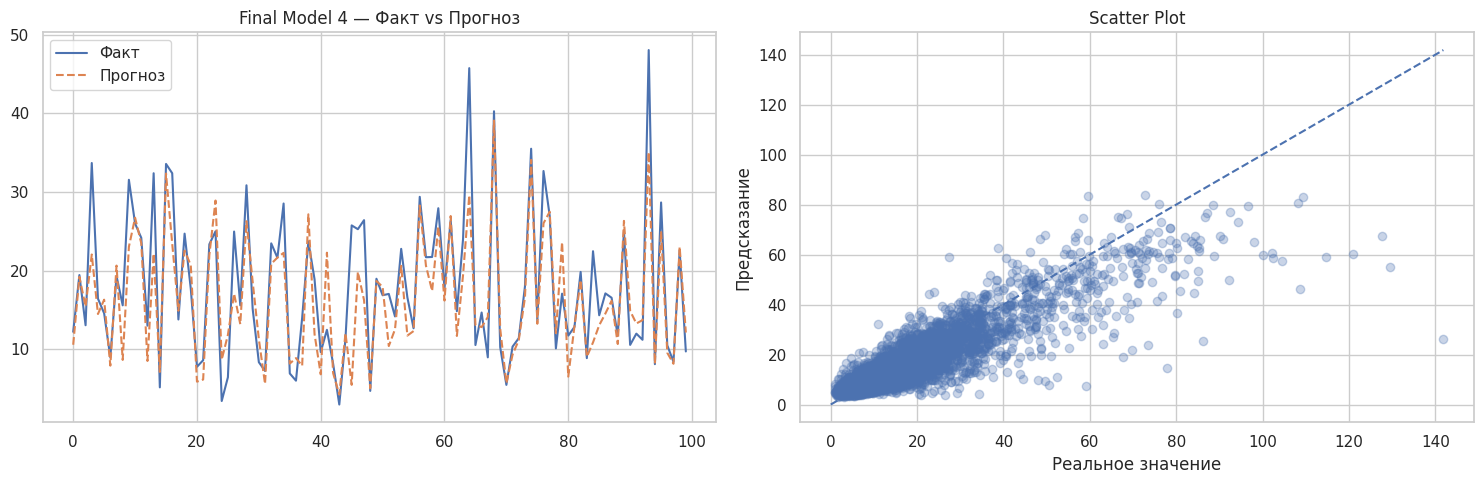

In [47]:

# ============================================
# Визуализация качества FINAL MODEL 4
# ============================================

sample = 100
scatter_sample = 5000

idx = np.random.choice(
    len(true_4),
    scatter_sample,
    replace=False
)

fig, axes = plt.subplots(
    1,2,
    figsize=(15,5)
)

# Линейное сравнение
axes[0].plot(
    true_4.iloc[:sample].values,
    label='Факт'
)

axes[0].plot(
    pred_4[:sample],
    '--',
    label='Прогноз'
)

axes[0].set_title('Final Model 4 — Факт vs Прогноз')
axes[0].legend()

# Scatter
axes[1].scatter(
    true_4.iloc[idx],
    pred_4[idx],
    alpha=0.3
)

axes[1].plot(
    [0, max(true_4.iloc[idx])],
    [0, max(true_4.iloc[idx])],
    '--'
)

axes[1].set_xlabel('Реальное значение')
axes[1].set_ylabel('Предсказание')
axes[1].set_title('Scatter Plot')

plt.tight_layout()
plt.show()


In [50]:
# ============================================
# Сохранение всех моделей
# ============================================

import joblib

joblib.dump(model, 'model_1_baseline.pkl')
joblib.dump(model2, 'model_2_improved.pkl')
joblib.dump(model3, 'model_3_geo_weather.pkl')
joblib.dump(model_4, 'model_4_final_boosted.pkl')

print("Все 4 модели успешно сохранены.")

Все 4 модели успешно сохранены.


In [51]:
# ============================================
# Загрузка моделей
# ============================================

model_1_loaded = joblib.load('model_1_baseline.pkl')
model_2_loaded = joblib.load('model_2_improved.pkl')
model_3_loaded = joblib.load('model_3_geo_weather.pkl')
model_4_loaded = joblib.load('model_4_final_boosted.pkl')

print("Модели успешно загружены.")

Модели успешно загружены.
